<a href="https://colab.research.google.com/github/xavierjacomep/marketing-basado-en-datos/blob/main/sistemas-recomendacion/Teor%C3%ADa_Sistemas_Recomendaci%C3%B3n_Optimizaci%C3%B3n_Precios.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
import warnings

warnings.filterwarnings('ignore')

# Estilo de gráficos
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

## SECCIÓN 1: DATOS SIMULADOS

In [2]:
def generar_datos_clientes(n_customers=1000):
    np.random.seed(42)
    return pd.DataFrame({
        'customer_id': range(1, n_customers + 1),
        'age': np.random.randint(18, 65, n_customers),
        'income': np.random.normal(50000, 15000, n_customers),
        'loyalty_score': np.random.uniform(0, 1, n_customers),
        'segment': np.random.choice(['Premium', 'Regular', 'Budget'], n_customers, p=[0.2, 0.5, 0.3])
    })

def generar_datos_productos(n_products=50):
    df = pd.DataFrame({
        'product_id': range(1, n_products + 1),
        'category': np.random.choice(['Electronics', 'Clothing', 'Books', 'Home'], n_products),
        'base_price': np.random.uniform(10, 500, n_products),
        'cost': np.random.uniform(5, 300, n_products),
        'popularity': np.random.uniform(0, 1, n_products)
    })
    df['margin'] = df['base_price'] - df['cost']
    return df

def generar_transacciones(customers_df, products_df, n_transactions=5000):
    transactions = []
    for _ in range(n_transactions):
        customer_id = np.random.randint(1, len(customers_df) + 1)
        product_id = np.random.randint(1, len(products_df) + 1)
        base_price = products_df.loc[products_df['product_id'] == product_id, 'base_price'].values[0]
        price_variation = np.random.uniform(0.8, 1.2)
        final_price = base_price * price_variation
        price_elasticity = -1.5
        quantity = max(1, int(2 * (base_price / final_price) ** (-price_elasticity)))
        transactions.append({
            'customer_id': customer_id,
            'product_id': product_id,
            'price': final_price,
            'quantity': quantity,
            'revenue': final_price * quantity,
            'date': pd.Timestamp('2024-01-01') + pd.Timedelta(days=np.random.randint(0, 365))
        })
    return pd.DataFrame(transactions)

In [3]:
# Generar datasets
customers_df = generar_datos_clientes()
products_df = generar_datos_productos()
transactions_df = generar_transacciones(customers_df, products_df)

In [6]:
print("Tamaño del DataFrame de Clientes:", customers_df.shape)
display(customers_df.head())

print("Tamaño del DataFrame de Productos:", products_df.shape)
display(products_df.head())

print("Tamaño del DataFrame de Transacciones:", transactions_df.shape)
display(transactions_df.head())

Tamaño del DataFrame de Clientes: (1000, 5)


,customer_id,age,income,loyalty_score,segment
0,1,56,65094.392138,0.458187,Budget
1,2,46,41346.621957,0.482969,Budget
2,3,32,62535.381681,0.133480,Regular
3,4,60,33054.397180,0.080602,Budget
4,5,25,57947.062669,0.727939,Premium


Tamaño del DataFrame de Productos: (50, 6)


,product_id,category,base_price,cost,popularity,margin
0,1,Electronics,210.143235,16.840963,0.050417,193.302271
1,2,Electronics,343.051636,267.524446,0.890384,75.527190
2,3,Home,37.773412,297.629010,0.576881,-259.855599
3,4,Home,26.989625,91.749901,0.563920,-64.760276
4,5,Electronics,202.036176,67.043974,0.500279,134.992202


Tamaño del DataFrame de Transacciones: (5000, 6)


,customer_id,product_id,price,quantity,revenue,date
0,936,13,145.156940,1,145.156940,2024-10-17
1,645,9,140.233032,1,140.233032,2024-04-04
2,790,2,357.752810,1,357.752810,2024-08-06
3,601,8,271.790065,2,543.580130,2024-07-30
4,940,23,155.355782,2,310.711563,2024-02-23


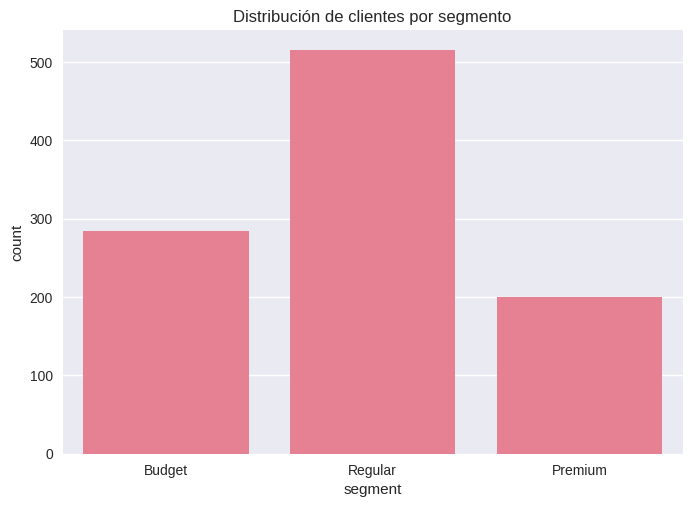

In [7]:
# Visualización rápida
sns.countplot(data=customers_df, x='segment')
plt.title("Distribución de clientes por segmento")
plt.show()

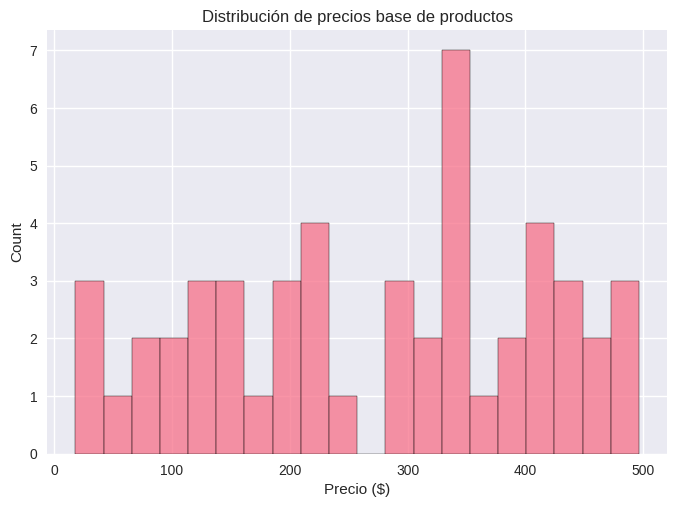

In [8]:
sns.histplot(products_df['base_price'], bins=20)
plt.title("Distribución de precios base de productos")
plt.xlabel("Precio ($)")
plt.show()

## SECCIÓN 2: SISTEMA DE RECOMENDACIONES

En esta sección desarrollamos un sistema de recomendación personalizado basado en **filtrado colaborativo**, con el objetivo de **sugerir productos relevantes a cada cliente** a partir de su historial de compras y el comportamiento de otros usuarios similares.

---

### ¿Qué es un sistema de recomendación?

Un sistema de recomendación predice los intereses o necesidades de un usuario y propone productos que aún no ha consumido, **mejorando la experiencia de compra y aumentando la conversión**.

Existen dos enfoques principales:

- **Filtrado colaborativo**: se basa en las preferencias de usuarios similares.
- **Filtrado basado en contenido**: se basa en las características del producto y del usuario.

En este caso, aplicamos **filtrado colaborativo basado en usuarios**, usando **similitud de coseno** para encontrar clientes con patrones de compra parecidos.

---

### ¿Cómo funciona nuestro modelo?

1. **Matriz usuario-producto**: construimos una tabla donde las filas son clientes, las columnas son productos, y los valores indican la cantidad comprada de cada producto.

2. **Similitud de usuarios**: calculamos la similitud de coseno entre vectores de compra para todos los pares de usuarios. Esta métrica nos dice qué tan parecidos son dos clientes en cuanto a los productos que compraron.

3. **Generación de recomendaciones**:
   - Para un cliente determinado, buscamos los usuarios más similares.
   - Para cada producto no comprado por el cliente, promediamos los "ratings" ponderados por similitud de los otros usuarios.
   - Devolvemos los productos con mayor score como **Top N recomendaciones personalizadas**.

---

### Ejemplo aplicado

Para el cliente `customer_id = 1`, se generaron las 5 mejores recomendaciones. Por ejemplo:

| Rank | Producto sugerido | Categoría | Score |
|------|-------------------|-----------|-------|
| 1    | Producto 17       | Clothing  | 1.72  |
| 2    | Producto 22       | Books     | 1.67  |

---

### Métricas y evaluación

Aunque en esta etapa no usamos métricas formales (como precisión, recall, F1 o NDCG), sí podemos evaluar el sistema de forma cualitativa:

- **Relevancia de los productos sugeridos** (ej. ¿pertenecen a la misma categoría de interés?)
- **Diversidad de las recomendaciones**
- **Consistencia entre usuarios similares**

---

### Aplicaciones empresariales

Los sistemas de recomendación son esenciales en:

- **E-commerce**: para mostrar productos relacionados y aumentar el ticket promedio.
- **Streaming**: para mantener el engagement del usuario.
- **Retail personalizado**: para estrategias de up-selling y cross-selling.

---

### ¿Qué evaluamos en esta sección?

1. Que el sistema construya correctamente la matriz usuario-producto.
2. Que la similitud entre usuarios refleje comportamientos reales.
3. Que las recomendaciones no incluyan productos ya comprados.
4. Que el sistema sea escalable a muchos usuarios/productos.

---

In [19]:
# Crear matriz usuario-producto: cada celda indica cuántas veces un cliente compró un producto
user_product_matrix = transactions_df.pivot_table(
    index='customer_id',
    columns='product_id',
    values='quantity',
    fill_value=0
)

display(user_product_matrix.head())

product_id,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50
customer_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,0.0,0.0,1.0,0.0,0.0,0.0,2.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,2.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,2.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,2.0,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [18]:
# En este caso usamos categoría como nombre simplificado (puedes modificar a tu gusto)
product_labels = products_df.set_index('product_id')['category'].to_dict()

# Renombrar las columnas de la matriz con el formato: "Producto {id} - {categoría}"
renamed_columns = {pid: f"Producto {pid} - {product_labels.get(pid, 'Desconocido')}"
                   for pid in user_product_matrix.columns}

# Crear nueva matriz con encabezados descriptivos
user_product_matrix_named = user_product_matrix.rename(columns=renamed_columns)
display(user_product_matrix_named.head())

product_id,Producto 1 - Electronics,Producto 2 - Electronics,Producto 3 - Home,Producto 4 - Home,Producto 5 - Electronics,Producto 6 - Home,Producto 7 - Electronics,Producto 8 - Clothing,Producto 9 - Home,Producto 10 - Home,Producto 11 - Home,Producto 12 - Clothing,Producto 13 - Electronics,Producto 14 - Books,Producto 15 - Home,Producto 16 - Electronics,Producto 17 - Clothing,Producto 18 - Books,Producto 19 - Home,Producto 20 - Clothing,Producto 21 - Clothing,Producto 22 - Books,Producto 23 - Electronics,Producto 24 - Home,Producto 25 - Home,Producto 26 - Electronics,Producto 27 - Electronics,Producto 28 - Electronics,Producto 29 - Books,Producto 30 - Books,Producto 31 - Home,Producto 32 - Books,Producto 33 - Clothing,Producto 34 - Home,Producto 35 - Books,Producto 36 - Electronics,Producto 37 - Clothing,Producto 38 - Electronics,Producto 39 - Home,Producto 40 - Electronics,Producto 41 - Books,Producto 42 - Books,Producto 43 - Home,Producto 44 - Electronics,Producto 45 - Home,Producto 46 - Electronics,Producto 47 - Clothing,Producto 48 - Books,Producto 49 - Home,Producto 50 - Clothing
customer_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,0.0,0.0,1.0,0.0,0.0,0.0,2.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,2.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,2.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,2.0,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [11]:
# Clase para el motor de recomendaciones basado en filtrado colaborativo por usuarios
class RecommendationEngine:
    def __init__(self, user_product_matrix):
        self.matrix = user_product_matrix
        self.user_similarity = None

    def calcular_similitud_usuarios(self):
        """Calcula la similitud entre clientes usando similitud de coseno"""
        self.user_similarity = cosine_similarity(self.matrix)
        return self.user_similarity

    def recomendar_productos(self, customer_id, n_recommendations=5):
        """Recomienda productos a un cliente con base en usuarios similares"""
        if self.user_similarity is None:
            self.calcular_similitud_usuarios()

        customer_idx = self.matrix.index.get_loc(customer_id)
        similar_customers = self.user_similarity[customer_idx]

        customer_products = self.matrix.loc[customer_id]
        productos_no_comprados = customer_products[customer_products == 0].index

        recomendaciones = {}

        for producto in productos_no_comprados:
            score = 0
            peso_total = 0
            for i, similarity in enumerate(similar_customers):
                if i != customer_idx and similarity > 0:
                    otro_cliente_id = self.matrix.index[i]
                    cantidad = self.matrix.loc[otro_cliente_id, producto]
                    if cantidad > 0:
                        score += similarity * cantidad
                        peso_total += similarity
            if peso_total > 0:
                recomendaciones[producto] = score / peso_total

        # Retornar top N recomendaciones ordenadas por score
        return sorted(recomendaciones.items(), key=lambda x: x[1], reverse=True)[:n_recommendations]

In [12]:
# Inicializar motor
rec_engine = RecommendationEngine(user_product_matrix)

In [21]:
# Calcular y mostrar la matriz de similitud entre usuarios usando coseno
similitud_usuarios = rec_engine.calcular_similitud_usuarios()

# Convertimos a DataFrame con índices de cliente para visualización clara
sim_matrix_df = pd.DataFrame(similitud_usuarios,
                             index=user_product_matrix.index,
                             columns=user_product_matrix.index)

# Mostrar parte superior izquierda de la matriz (primeros 10 clientes)
sim_matrix_sub = sim_matrix_df.iloc[:10, :]
display(sim_matrix_sub.head(10))

customer_id      1         2         3         4         5         6     \
customer_id                                                               
1            1.000000  0.000000  0.068041  0.218218  0.117851  0.000000   
2            0.000000  1.000000  0.161690  0.129641  0.140028  0.000000   
3            0.068041  0.161690  1.000000  0.178174  0.000000  0.000000   
4            0.218218  0.129641  0.178174  1.000000  0.000000  0.000000   
5            0.117851  0.140028  0.000000  0.000000  1.000000  0.000000   
6            0.000000  0.000000  0.000000  0.000000  0.000000  1.000000   
7            0.166667  0.000000  0.136083  0.218218  0.000000  0.000000   
8            0.000000  0.000000  0.251976  0.000000  0.327327  0.000000   
9            0.000000  0.250490  0.000000  0.000000  0.000000  0.179787   
10           0.000000  0.117647  0.242536  0.064820  0.000000  0.000000   

customer_id      7         8         9         10        11        12    \
customer_id                                                               
1            0.166667  0.000000  0.000000  0.000000  0.136083  0.234146   
2            0.000000  0.000000  0.250490  0.117647  0.000000  0.000000   
3            0.136083  0.251976  0.000000  0.242536  0.000000  0.382360   
4            0.218218  0.000000  0.000000  0.064820  0.000000  0.306570   
5            0.000000  0.327327  0.000000  0.000000  0.000000  0.000000   
6            0.000000  0.000000  0.179787  0.000000  0.116052  0.239617   
7            1.000000  0.000000  0.000000  0.396059  0.000000  0.374634   
8            0.000000  1.000000  0.000000  0.366679  0.000000  0.000000   
9            0.000000  0.000000  1.000000  0.187867  0.000000  0.236940   
10           0.396059  0.366679  0.187867  1.000000  0.000000  0.000000   

customer_id      13        14        15        16        17        18    \
customer_id                                                               
1            0.000000  0.144338  0.099015  0.123091  0.000000  0.000000   
2            0.280056  0.171499  0.000000  0.146254  0.000000  0.277184   
3            0.288675  0.471405  0.080845  0.201008  0.210819  0.142857   
4            0.154303  0.283473  0.000000  0.000000  0.000000  0.152721   
5            0.166667  0.000000  0.140028  0.087039  0.365148  0.329914   
6            0.000000  0.184637  0.000000  0.104973  0.220193  0.000000   
7            0.000000  0.000000  0.396059  0.000000  0.258199  0.000000   
8            0.218218  0.000000  0.366679  0.455842  0.239046  0.323970   
9            0.000000  0.000000  0.000000  0.077850  0.000000  0.000000   
10           0.210042  0.085749  0.470588  0.292509  0.000000  0.207888   

customer_id      19        20        21        22        23        24    \
customer_id                                                               
1            0.280976  0.154303  0.000000  0.166667  0.000000  0.000000   
2            0.000000  0.091670  0.000000  0.000000  0.323381  0.280056   
3            0.152944  0.000000  0.000000  0.272166  0.000000  0.192450   
4            0.306570  0.000000  0.000000  0.000000  0.178174  0.077152   
5            0.132453  0.000000  0.000000  0.000000  0.000000  0.000000   
6            0.000000  0.131590  0.000000  0.000000  0.116052  0.000000   
7            0.000000  0.000000  0.000000  0.000000  0.000000  0.471405   
8            0.086711  0.000000  0.000000  0.000000  0.000000  0.000000   
9            0.059235  0.000000  0.000000  0.000000  0.000000  0.372678   
10           0.055641  0.000000  0.171499  0.000000  0.161690  0.280056   

customer_id      25        26        27        28        29        30    \
customer_id                                                               
1            0.117851  0.000000  0.182574  0.109109  0.000000  0.000000   
2            0.280056  0.306786  0.000000  0.000000  0.613572  0.000000   
3            0.384900  0.000000  0.000000  0.000000  0.000000  0.000000   
4            0.000000

In [23]:
# Encontrar la columna (customer_id) con el valor máximo para customer_id 1, excluyendo customer_id 1
max_similarity_column = sim_matrix_sub.loc[1].drop(1).idxmax()

# Imprimir el resultado
print(f"El customer_id con la máxima similitud para el customer_id 1 en sim_matrix_sub (excluyendo 1) es: {max_similarity_column}")

# Opcional: mostrar el valor de similitud
max_similarity_value = sim_matrix_sub.loc[1].drop(1).max()
print(f"Valor de similitud máxima (excluyendo 1): {max_similarity_value:.4f}")

El customer_id con la máxima similitud para el customer_id 1 en sim_matrix_sub (excluyendo 1) es: 890
Valor de similitud máxima (excluyendo 1): 0.5443


In [24]:
# Mostrar las filas para customer_id 1 y 890
display(user_product_matrix_named.loc[[1, 890]])

product_id,Producto 1 - Electronics,Producto 2 - Electronics,Producto 3 - Home,Producto 4 - Home,Producto 5 - Electronics,Producto 6 - Home,Producto 7 - Electronics,Producto 8 - Clothing,Producto 9 - Home,Producto 10 - Home,Producto 11 - Home,Producto 12 - Clothing,Producto 13 - Electronics,Producto 14 - Books,Producto 15 - Home,Producto 16 - Electronics,Producto 17 - Clothing,Producto 18 - Books,Producto 19 - Home,Producto 20 - Clothing,Producto 21 - Clothing,Producto 22 - Books,Producto 23 - Electronics,Producto 24 - Home,Producto 25 - Home,Producto 26 - Electronics,Producto 27 - Electronics,Producto 28 - Electronics,Producto 29 - Books,Producto 30 - Books,Producto 31 - Home,Producto 32 - Books,Producto 33 - Clothing,Producto 34 - Home,Producto 35 - Books,Producto 36 - Electronics,Producto 37 - Clothing,Producto 38 - Electronics,Producto 39 - Home,Producto 40 - Electronics,Producto 41 - Books,Producto 42 - Books,Producto 43 - Home,Producto 44 - Electronics,Producto 45 - Home,Producto 46 - Electronics,Producto 47 - Clothing,Producto 48 - Books,Producto 49 - Home,Producto 50 - Clothing
customer_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,0.0,0.0,1.0,0.0,0.0,0.0,2.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,2.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
890,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [13]:
# Ejemplo de recomendaciones para un cliente
cliente_ejemplo = 1
recomendaciones = rec_engine.recomendar_productos(cliente_ejemplo, n_recommendations=5)

print(f"\n🎯 Recomendaciones para Cliente {cliente_ejemplo}:")
for i, (product_id, score) in enumerate(recomendaciones, 1):
    info = products_df[products_df['product_id'] == product_id].iloc[0]
    print(f"   {i}. Producto {product_id} ({info['category']}) - Score: {score:.2f}")


🎯 Recomendaciones para Cliente 1:
   1. Producto 17 (Clothing) - Score: 1.72
   2. Producto 22 (Books) - Score: 1.67
   3. Producto 37 (Clothing) - Score: 1.66
   4. Producto 18 (Books) - Score: 1.61
   5. Producto 49 (Home) - Score: 1.59


In [25]:
# Generar top 5 recomendaciones para todos los clientes
top_recommendaciones = []

# Limitamos a primeros 100 clientes para hacerlo manejable en memoria
clientes_sample = user_product_matrix.index[:100]

for cid in clientes_sample:
    recomendaciones = rec_engine.recomendar_productos(cid, n_recommendations=5)
    for rank, (product_id, score) in enumerate(recomendaciones, start=1):
        producto = products_df[products_df['product_id'] == product_id].iloc[0]
        top_recommendaciones.append({
            'customer_id': cid,
            'rank': rank,
            'product_id': product_id,
            'categoria': producto['category'],
            'score_recomendacion': round(score, 2),
            'precio_base': round(producto['base_price'], 2)
        })

# Crear DataFrame para mostrar
recom_df = pd.DataFrame(top_recommendaciones)
display(recom_df.head(50))

,customer_id,rank,product_id,categoria,score_recomendacion,precio_base
0,1,1,17,Clothing,1.72,414.77
1,1,2,22,Books,1.67,371.60
2,1,3,37,Clothing,1.66,313.50
3,1,4,18,Books,1.61,339.82
4,1,5,49,Home,1.59,17.94
5,2,1,43,Home,1.74,108.75
6,2,2,49,Home,1.63,17.94
7,2,3,1,Electronics,1.61,210.14
8,2,4,10,Home,1.60,444.18
9,2,5,41,Books,1.58,286.47


## SECCIÓN 3: OPTIMIZACIÓN DE PRECIOS

Este bloque de código desarrolla un sistema completo para **proponer precios óptimos por producto y segmento de cliente**, apoyado en la teoría de la **elasticidad-precio de la demanda**, simulación de impacto financiero, y visualización para toma de decisiones.

---

### Fundamento Teórico: Elasticidad-Precio de la Demanda

La elasticidad-precio de la demanda mide cómo varía la cantidad demandada de un producto ante cambios en su precio:

$
\text{Elasticidad} = \frac{\% \Delta \text{Demanda}}{\% \Delta \text{Precio}}
$

- Si **Elasticidad < -1** → Demanda elástica: bajar precios genera aumento significativo de ventas.
- Si **Elasticidad > -1** → Demanda inelástica: subir precios puede aumentar ingresos con menor pérdida de volumen.

---

### Módulo: Clase `PriceOptimizer`

### Objetivo:
Automatizar el cálculo de elasticidad y proponer precios ajustados para diferentes segmentos de clientes.

#### Métodos Clave:

##### `calcular_elasticidad(product_id)`
- Agrupa ventas del producto por rangos de precio.
- Calcula elasticidad como variación relativa entre extremos de precio y cantidad vendida.
- Usa valor por defecto si hay pocos datos.

##### `proponer_precio(product_id, segmento)`
- Según elasticidad calculada, propone un precio más bajo (si elástica) o más alto (si inelástica).
- Aplica un multiplicador según el segmento:
  - `Premium`: 1.2x
  - `Regular`: 1.0x
  - `Budget`: 0.8x
- Garantiza que el nuevo precio supere el costo + margen mínimo (20%).

---

### Simulación de Impacto Comercial

Para cada producto-segmento:

1. Se calcula el **cambio porcentual en precio**.
2. Se estima el **cambio en demanda usando elasticidad**.
3. Se simula:
   - **Ingreso base**: precio original × demanda original.
   - **Ingreso optimizado**: nuevo precio × demanda estimada.
   - **Ganancia o pérdida esperada**.

Esto permite comparar el ingreso antes y después de aplicar la nueva política de precios.

---

### Clasificación Estratégica

Se define una estrategia sugerida según dos factores:
- El **ingreso incremental** (ganancia o pérdida esperada).
- El tipo de **demanda (elástica o inelástica)**.

Las estrategias posibles son:
- 📉 **Bajar precio** para captar más volumen si la demanda es sensible.
- 📈 **Subir precio** si hay baja sensibilidad al precio.
- ⚠️ **Revisar estrategia** si el ingreso disminuye significativamente.
- ➕ **Ajuste marginal** si el impacto es leve.

---

### Visualización y Comunicación

#### Gráfico 1: Incremento de Ingreso por Segmento y Producto
- Compara la ganancia potencial por cliente según el nuevo precio.
- Permite identificar productos más sensibles o más rentables.

#### Gráfico 2: Estrategias Sugeridas por Segmento
- Muestra la frecuencia de cada tipo de estrategia para cada segmento (`Premium`, `Regular`, `Budget`).
- Permite priorizar esfuerzos comerciales por perfil de cliente.

---

### Aplicaciones Estratégicas

Este flujo analítico permite:
- Aplicar **precios diferenciados por segmento** sin improvisación.
- Simular efectos antes de ejecutar cambios.
- Sostener decisiones comerciales con **evidencia cuantitativa**.

Puede integrarse fácilmente con:
- Motores de recomendación de productos.
- Estrategias de fidelización con incentivos.
- A/B Testing para validar hipótesis de impacto.

---


In [26]:
# Clase para calcular elasticidad y proponer precios óptimos
class PriceOptimizer:
    def __init__(self, transactions_df, products_df):
        self.transactions = transactions_df
        self.products = products_df
        self.elasticity_store = {}

    def calcular_elasticidad(self, product_id):
        """Calcula elasticidad-precio de la demanda para un producto específico"""
        df = self.transactions[self.transactions['product_id'] == product_id].copy()
        if len(df) < 10:
            return -1.5  # Valor por defecto si hay pocos datos

        # Agrupar por rangos de precio y calcular demanda total por rango
        df['price_bin'] = pd.cut(df['price'], bins=5)
        agrupado = df.groupby('price_bin').agg({'price': 'mean', 'quantity': 'sum'}).reset_index()

        if len(agrupado) < 2:
            return -1.5

        # Elasticidad simple: % cambio en demanda / % cambio en precio
        pct_cambio_precio = (agrupado['price'].iloc[-1] - agrupado['price'].iloc[0]) / agrupado['price'].iloc[0]
        pct_cambio_demanda = (agrupado['quantity'].iloc[-1] - agrupado['quantity'].iloc[0]) / agrupado['quantity'].iloc[0]

        if pct_cambio_precio == 0:
            return -1.5

        elasticidad = pct_cambio_demanda / pct_cambio_precio
        self.elasticity_store[product_id] = elasticidad
        return elasticidad

    def proponer_precio(self, product_id, segmento='Regular'):
        """Devuelve el precio óptimo ajustado al segmento del cliente"""
        info = self.products[self.products['product_id'] == product_id].iloc[0]
        base_price = info['base_price']
        cost = info['cost']
        elasticidad = self.calcular_elasticidad(product_id)

        # Ajustes por tipo de cliente
        multiplicador_segmento = {
            'Premium': 1.2,
            'Regular': 1.0,
            'Budget': 0.8
        }

        if elasticidad < -1:  # Alta sensibilidad
            precio_ajustado = base_price * 0.9 * multiplicador_segmento[segmento]
        else:  # Poca sensibilidad
            precio_ajustado = base_price * 1.1 * multiplicador_segmento[segmento]

        # Validación: el precio debe cubrir el costo
        precio_ajustado = max(precio_ajustado, cost * 1.2)

        return {
            'product_id': product_id,
            'segment': segmento,
            'base_price': base_price,
            'optimal_price': precio_ajustado,
            'cost': cost,
            'elasticity': elasticidad,
            'margin_delta': (precio_ajustado - cost) - (base_price - cost)
        }


In [27]:
# Inicializar optimizador
optimizador = PriceOptimizer(transactions_df, products_df)

In [28]:
# Probar con productos y segmentos ejemplo
productos_ejemplo = [1, 5, 10]
segmentos = ['Premium', 'Regular', 'Budget']
resultados_optimizacion = []

print("📈 Optimización de Precios por Producto y Segmento:")
print("-" * 60)

for prod in productos_ejemplo:
    for seg in segmentos:
        resultado = optimizador.proponer_precio(prod, seg)
        resultados_optimizacion.append(resultado)

        # Mostrar solo Regular en clase para simplificar visual
        if seg == 'Regular':
            print(f"Producto {prod:2d} | Segmento: {seg:8s} | Base: ${resultado['base_price']:6.2f} → Óptimo: ${resultado['optimal_price']:6.2f} "
                  f"| Elasticidad: {resultado['elasticity']:.2f}")

📈 Optimización de Precios por Producto y Segmento:
------------------------------------------------------------
Producto  1 | Segmento: Regular  | Base: $210.14 → Óptimo: $189.13 | Elasticidad: -1.40
Producto  5 | Segmento: Regular  | Base: $202.04 → Óptimo: $181.83 | Elasticidad: -1.56
Producto 10 | Segmento: Regular  | Base: $444.18 → Óptimo: $399.76 | Elasticidad: -1.92


In [29]:
# Supuestos para la simulación
cantidad_base = 100  # supongamos 100 unidades vendidas al precio base

# Calcular ingreso base y optimizado, y efecto en la demanda
tabla_impacto_precios = []
for res in resultados_optimizacion:
    base_price = res['base_price']
    opt_price = res['optimal_price']
    elasticity = res['elasticity']

    # Estimar cambio porcentual en precio
    pct_cambio_precio = (opt_price - base_price) / base_price

    # Estimar nuevo volumen según elasticidad
    pct_cambio_demanda = elasticity * pct_cambio_precio
    nueva_demanda = cantidad_base * (1 + pct_cambio_demanda)

    # Ingresos
    ingreso_base = base_price * cantidad_base
    ingreso_optimo = opt_price * nueva_demanda

    tabla_impacto_precios.append({
        'product_id': res['product_id'],
        'segmento': res['segment'],
        'precio_base': round(base_price, 2),
        'precio_optimo': round(opt_price, 2),
        'elasticidad': round(elasticity, 2),
        'cambio_demanda_%': round(pct_cambio_demanda * 100, 2),
        'nueva_demanda': int(nueva_demanda),
        'ingreso_base': round(ingreso_base, 2),
        'ingreso_optimo': round(ingreso_optimo, 2),
        'ingreso_incremento': round(ingreso_optimo - ingreso_base, 2)
    })

# Convertir a DataFrame y mostrar
df_impacto_precios = pd.DataFrame(tabla_impacto_precios)
display(df_impacto_precios.head())

,product_id,segmento,precio_base,precio_optimo,elasticidad,cambio_demanda_%,nueva_demanda,ingreso_base,ingreso_optimo,ingreso_incremento
0,1,Premium,210.14,226.95,-1.40,-11.23,88,21014.32,20146.94,-867.39
1,1,Regular,210.14,189.13,-1.40,14.04,114,21014.32,21567.61,553.29
2,1,Budget,210.14,151.30,-1.40,39.30,139,21014.32,21076.89,62.57
3,5,Premium,202.04,218.20,-1.56,-12.48,87,20203.62,19096.87,-1106.74
4,5,Regular,202.04,181.83,-1.56,15.60,115,20203.62,21019.75,816.13


In [31]:
def clasificar_estrategia(row):
    """
    Define una estrategia sugerida en base al cambio de ingresos y elasticidad:
    """
    if row['ingreso_incremento'] > 500:
        if row['elasticidad'] < -1:
            return "Bajar precio para captar volumen (Demanda Elástica)"
        else:
            return "Subir precio, baja sensibilidad (Demanda Inelástica)"
    elif row['ingreso_incremento'] < -500:
        return "Revisar estrategia: pérdida esperada significativa"
    else:
        return "Ajuste marginal viable según segmento"

# Aplicar clasificación
df_impacto_precios['estrategia_sugerida'] = df_impacto_precios.apply(clasificar_estrategia, axis=1)
display(df_impacto_precios.head())

,product_id,segmento,precio_base,precio_optimo,elasticidad,cambio_demanda_%,nueva_demanda,ingreso_base,ingreso_optimo,ingreso_incremento,estrategia_sugerida
0,1,Premium,210.14,226.95,-1.40,-11.23,88,21014.32,20146.94,-867.39,Revisar estrategia: pérdida esperada significa...
1,1,Regular,210.14,189.13,-1.40,14.04,114,21014.32,21567.61,553.29,Bajar precio para captar volumen (Demanda Elás...
2,1,Budget,210.14,151.30,-1.40,39.30,139,21014.32,21076.89,62.57,Ajuste marginal viable según segmento
3,5,Premium,202.04,218.20,-1.56,-12.48,87,20203.62,19096.87,-1106.74,Revisar estrategia: pérdida esperada significa...
4,5,Regular,202.04,181.83,-1.56,15.60,115,20203.62,21019.75,816.13,Bajar precio para captar volumen (Demanda Elás...


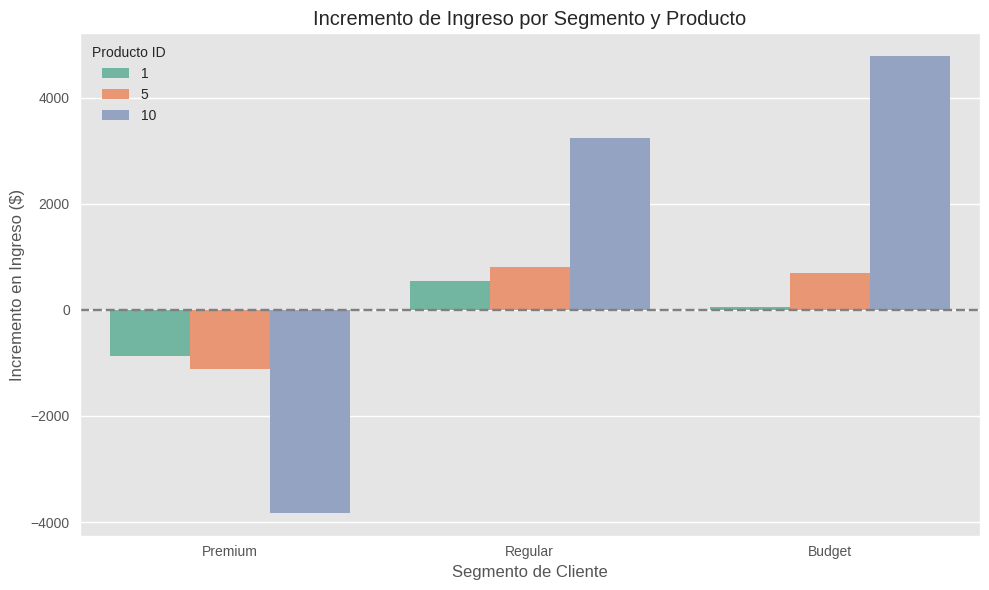

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ajustar estilo visual
plt.style.use("ggplot")

# Gráfico 1: Ingreso incremental por segmento
plt.figure(figsize=(10, 6))
sns.barplot(
    data=df_impacto_precios,
    x='segmento',
    y='ingreso_incremento',
    hue='product_id',
    palette='Set2'
)
plt.title("Incremento de Ingreso por Segmento y Producto")
plt.ylabel("Incremento en Ingreso ($)")
plt.xlabel("Segmento de Cliente")
plt.axhline(0, color='gray', linestyle='--')
plt.legend(title='Producto ID')
plt.tight_layout()
plt.show()

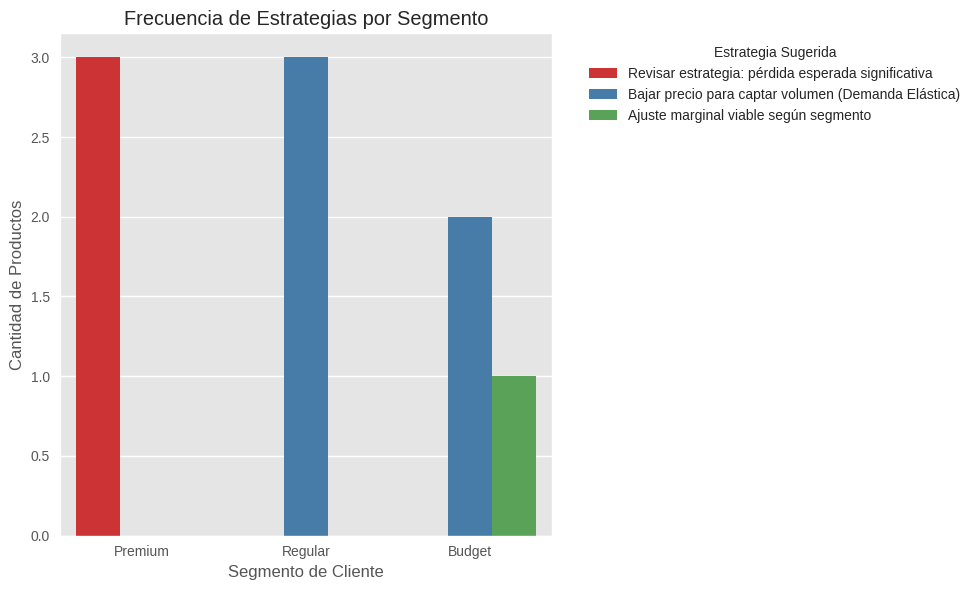

In [33]:
# Gráfico 2: Estrategias sugeridas por segmento
plt.figure(figsize=(10, 6))
sns.countplot(
    data=df_impacto_precios,
    x='segmento',
    hue='estrategia_sugerida',
    palette='Set1'
)
plt.title("Frecuencia de Estrategias por Segmento")
plt.ylabel("Cantidad de Productos")
plt.xlabel("Segmento de Cliente")
plt.xticks(rotation=0)
plt.legend(title="Estrategia Sugerida", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## SECCIÓN 4: INCENTIVOS PERSONALIZADOS

Esta sección presenta una implementación práctica de un **motor de incentivos personalizados**, que combina segmentación de clientes con evaluación de riesgo de abandono (churn) para **asignar incentivos específicos por usuario**. Este enfoque ayuda a **maximizar la retención de clientes** y optimizar el retorno de las campañas promocionales.

---

### Lógica del Modelo: `IncentiveEngine`

Se define una clase modular capaz de:
1. **Construir métricas clave por cliente** a partir del historial de transacciones.
2. **Estimar riesgo de abandono** (score de churn) usando reglas basadas en:
   - Días desde última compra
   - Frecuencia de compra
   - Nivel de lealtad (`loyalty_score`)
3. **Asignar un incentivo personalizado** con base en el riesgo y el segmento del cliente.

---

### Método: `_construir_metricas_clientes()`

Calcula KPIs por cliente, tales como:
- Total gastado (`total_revenue`)
- Valor promedio de pedido (`avg_order_value`)
- Número de compras
- Días desde la última compra (proxy del riesgo)
- Segmento del cliente (Premium, Regular, Budget)

Estas variables son esenciales para crear reglas de retención y marketing one-to-one.

---

### Método: `calcular_riesgo_churn()`

Simula un score de churn ∈ [0, 1], combinando:
- Tiempo desde la última compra (más días = más riesgo)
- Frecuencia de compra (más compras = menos riesgo)
- Nivel de lealtad (score entre 0 y 1)

Este score pondera los tres factores para estimar el abandono de forma razonable y comprensible para el negocio.

---

### Método: `generar_incentivo()`

Define incentivos personalizados basados en:
- **Riesgo de churn estimado**
- **Segmento del cliente**

Cada segmento tiene lógica de decisión distinta:
- **Premium**: experiencias VIP, descuentos moderados, urgencia alta.
- **Regular**: descuentos medios o programa de puntos.
- **Budget**: incentivos de bajo costo como cupones o envío gratuito.

Se retorna un diccionario con:
- Tipo de incentivo
- Descripción para CRM o emailing
- Descuento estimado
- Nivel de urgencia (Alta/Media/Baja)
- Impacto estimado (% de retención esperada)

---


In [34]:
class IncentiveEngine:
    def __init__(self, customers_df, transactions_df):
        self.customers_df = customers_df
        self.transactions_df = transactions_df
        self.metrics_df = self._construir_metricas_clientes()

    def _construir_metricas_clientes(self):
        """Calcula KPIs históricos por cliente a partir de las transacciones"""
        stats = self.transactions_df.groupby('customer_id').agg({
            'revenue': ['sum', 'mean', 'count'],
            'quantity': 'sum',
            'date': ['min', 'max']
        })
        stats.columns = ['total_revenue', 'avg_order_value', 'purchase_count',
                         'total_items', 'first_purchase', 'last_purchase']
        stats = stats.round(2)

        # Días desde última compra (para riesgo de abandono)
        stats['days_since_last_purchase'] = (
            pd.Timestamp('2024-12-31') - stats['last_purchase']
        ).dt.days

        # Enlazar con datos de clientes
        return self.customers_df.merge(stats, on='customer_id', how='left')

    def calcular_riesgo_churn(self, customer_id):
        """Calcula un score de riesgo de abandono entre 0 y 1"""
        cliente = self.metrics_df[self.metrics_df['customer_id'] == customer_id].iloc[0]
        riesgo = (
            min(cliente['days_since_last_purchase'] / 180, 1) * 0.4 +
            (1 - min(cliente['purchase_count'] / 10, 1)) * 0.3 +
            (1 - cliente['loyalty_score']) * 0.3
        )
        return round(min(riesgo, 1), 2)

    def generar_incentivo(self, customer_id):
        """Devuelve un incentivo personalizado en función del riesgo y segmento"""
        cliente = self.metrics_df[self.metrics_df['customer_id'] == customer_id].iloc[0]
        segmento = cliente['segment']
        riesgo = self.calcular_riesgo_churn(customer_id)

        if segmento == 'Premium':
            incentivo = {
                'type': 'Acceso Exclusivo' if riesgo > 0.7 else 'Experiencia Premium',
                'description': 'Acceso VIP + 15% dto' if riesgo > 0.7 else 'Consultoría personal gratuita',
                'discount_pct': 15 if riesgo > 0.7 else 0,
                'urgency': 'Alta' if riesgo > 0.7 else 'Media'
            }
        elif segmento == 'Regular':
            incentivo = {
                'type': 'Descuento Personalizado' if riesgo > 0.6 else 'Programa de Puntos',
                'description': f"10% en compras > ${cliente['avg_order_value']:.0f}" if riesgo > 0.6 else "Puntos dobles próxima compra",
                'discount_pct': 10 if riesgo > 0.6 else 5,
                'urgency': 'Alta' if riesgo > 0.6 else 'Baja'
            }
        else:  # Budget
            incentivo = {
                'type': 'Oferta Especial' if riesgo > 0.5 else 'Recompensa Lealtad',
                'description': "Envío gratis + 5% dto" if riesgo > 0.5 else "Cupón de $10 próxima compra",
                'discount_pct': 5 if riesgo > 0.5 else 0,
                'urgency': 'Alta' if riesgo > 0.5 else 'Baja'
            }

        incentivo.update({
            'customer_id': customer_id,
            'segment': segmento,
            'churn_risk': riesgo,
            'estimated_impact': min(riesgo * 100, 50)  # impacto esperado en conversión
        })

        return incentivo

In [35]:
# Inicializar motor de incentivos
incentivos = IncentiveEngine(customers_df, transactions_df)

In [36]:
# Probar con muestra de clientes
clientes_muestra = [1, 15, 30, 45, 60]
resultados_incentivos = []

print("🎁 Incentivos Personalizados Generados:")
print("-" * 70)
for cid in clientes_muestra:
    inc = incentivos.generar_incentivo(cid)
    resultados_incentivos.append(inc)
    print(f"Cliente {cid:2d} ({inc['segment']}) | Riesgo: {inc['churn_risk']:.2f} | "
          f"{inc['type']:20s} | Impacto Estimado: +{inc['estimated_impact']:.0f}%")

🎁 Incentivos Personalizados Generados:
----------------------------------------------------------------------
Cliente  1 (Budget) | Riesgo: 0.48 | Recompensa Lealtad   | Impacto Estimado: +48%
Cliente 15 (Premium) | Riesgo: 0.31 | Experiencia Premium  | Impacto Estimado: +31%
Cliente 30 (Regular) | Riesgo: 0.46 | Programa de Puntos   | Impacto Estimado: +46%
Cliente 45 (Budget) | Riesgo: 0.75 | Oferta Especial      | Impacto Estimado: +50%
Cliente 60 (Budget) | Riesgo: 0.52 | Oferta Especial      | Impacto Estimado: +50%
